<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/anthony-ver/notebooks/ablacion_formulaciones_ignicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de fórmulas de ignición

In [1]:
import os
import sys
from pathlib import Path

RAMA_REPO = "anthony-ver"

if os.path.exists('src'):
    PROJECT_ROOT = Path('.').resolve()
elif os.path.exists('../src'):
    PROJECT_ROOT = Path('..').resolve()
else:
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone -b {RAMA_REPO} https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata
    PROJECT_ROOT = Path('.').resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

from src.model.grid import Grid, QUEMANDOSE, QUEMADA, NO_COMBUSTIBLE, AGUA
from src.model.wind_influence import WindField, DEFAULT_C1, DEFAULT_C2, calculate_wind_factor
from src.model.ignicion_propagator import (
    FormulacionPropagator, P_AUTOCONTAGIO_MAX, P_NOMINAL, NOMBRES_COMBUSTIBLE,
    vegetacion_equivalente, factor_viento_pendiente, probabilidad_propagacion,
    LATIFOLIADAS, MATORRAL, PASTIZAL, AGROFORESTAL, NO_VEGETADO, SIN_COMBUSTIBLE,
)
from src.viz.plot_grid import dibujar_grid

Cloning into 'wildfire-cellular-automata'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (216/216), done.
remote: Total 270 (delta 93), reused 194 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (270/270), 3.73 MiB | 15.17 MiB/s, done.
Resolving deltas: 100% (93/93), done.
/content/wildfire-cellular-automata


## Las 2 formulaciones

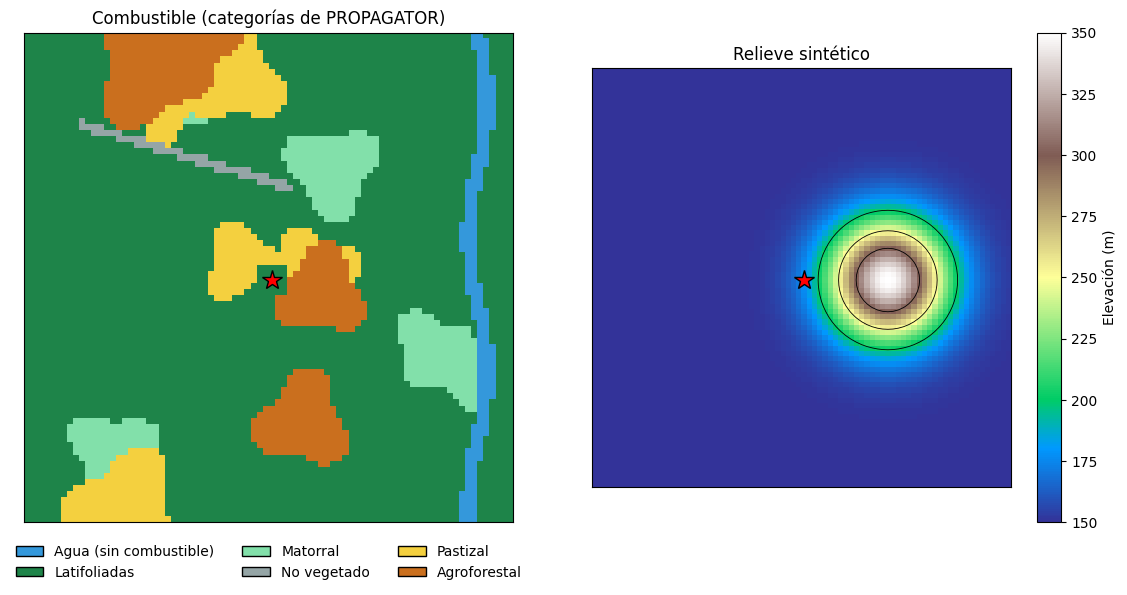

Cobertura: Agua (sin combustible) 3.2%, Latifoliadas 73.7%, Matorral 6.4%, No vegetado 0.8%, Pastizal 7.1%, Agroforestal 8.9%
Pendiente máxima entre celdas: 26.7°


In [2]:
N = 80
TAMANO_CELDA = 30.0
HA_POR_CELDA = TAMANO_CELDA ** 2 / 1e4
rng = np.random.default_rng(2026)
filas, cols = np.mgrid[0:N, 0:N]

combustible = np.full((N, N), LATIFOLIADAS, dtype=np.int64)
for codigo, n_manchas, (r_min, r_max) in [(MATORRAL, 6, (4, 8)), (PASTIZAL, 5, (4, 9)), (AGROFORESTAL, 4, (5, 10))]:
    for _ in range(n_manchas):
        f0, c0 = rng.integers(0, N, 2)
        radio = rng.uniform(r_min, r_max)
        angulo = np.arctan2(filas - f0, cols - c0)
        borde = radio * (1 + 0.25 * np.sin(3 * angulo + rng.uniform(0, 2 * np.pi)))
        combustible[np.hypot(filas - f0, cols - c0) < borde] = codigo

RIO = np.abs(cols - (0.92 * N + 1.5 * np.sin(filas / 7.0))) < 1.2
CAMINO = (np.abs(filas - (0.15 * N + 0.3 * cols)) < 0.8) & (cols > 0.1 * N) & (cols < 0.55 * N)
combustible[RIO] = SIN_COMBUSTIBLE
combustible[CAMINO] = NO_VEGETADO

FOCO = (40, 40)
combustible[38:43, 38:43] = LATIFOLIADAS

ELEVACION = 150 + 200 * np.exp(-((filas - 40) ** 2 + (cols - 56) ** 2) / (2 * 8.0 ** 2))

VEGETACION = vegetacion_equivalente(combustible)

COLORES_COMBUSTIBLE = {0: "#3498db", 1: "#1e8449", 2: "#82e0aa", 3: "#95a5a6",
                       4: "#f4d03f", 5: "#145a32", 6: "#ca6f1e", 7: "#6c3483"}
cmap_comb = ListedColormap([COLORES_COMBUSTIBLE[k] for k in range(8)])
norma_comb = BoundaryNorm(np.arange(-0.5, 8.5, 1), cmap_comb.N)
presentes = np.unique(combustible)
etiqueta = lambda k: "Agua (sin combustible)" if k == SIN_COMBUSTIBLE else NOMBRES_COMBUSTIBLE[k]

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.8))
ejes[0].imshow(combustible, cmap=cmap_comb, norm=norma_comb, interpolation="nearest")
ejes[0].legend(handles=[Patch(facecolor=COLORES_COMBUSTIBLE[k], edgecolor="k", label=etiqueta(k)) for k in presentes],
               loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
ejes[0].set_title("Combustible (categorías de PROPAGATOR)")
im = ejes[1].imshow(ELEVACION, cmap="terrain")
ejes[1].contour(ELEVACION, levels=[200, 250, 300], colors="k", linewidths=0.6)
fig.colorbar(im, ax=ejes[1], label="Elevación (m)")
ejes[1].set_title("Relieve sintético")
for ax in ejes:
    ax.plot(FOCO[1], FOCO[0], "r*", ms=15, mec="k")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Cobertura:", ", ".join(f"{etiqueta(k)} {(combustible == k).mean():.1%}" for k in presentes))
print(f"Pendiente máxima entre celdas: {np.degrees(np.arctan(np.abs(np.diff(ELEVACION, axis=1)).max() / TAMANO_CELDA)):.1f}°")

In [3]:
PASOS = 30
N_CORRIDAS = 40
PROPAGATOR = FormulacionPropagator(combustible, elevacion=ELEVACION, tamano_celda_m=TAMANO_CELDA)
VIENTO_MODERADO = WindField(speed_ms=6.0, wind_deg=270.0)
VIENTO_FUERTE = WindField(speed_ms=12.0, wind_deg=270.0)

def correr(formulacion, semilla, viento, pasos_para_quemarse, devolver_grid=False):
    grid = Grid(tamano=N, prob_ignicion_base=P_AUTOCONTAGIO_MAX,
                pasos_para_quemarse=pasos_para_quemarse, semilla=semilla)
    grid.vegetacion = VEGETACION.copy()
    grid.estado[RIO] = AGUA
    grid.estado[CAMINO] = NO_COMBUSTIBLE
    grid.encender_celda(*FOCO)
    for _ in range(PASOS):
        grid.paso_tiempo(campo_viento=viento, formulacion=formulacion)
    return grid if devolver_grid else np.isin(grid.estado, [QUEMANDOSE, QUEMADA])

def ensamble(formulacion, viento, pasos_para_quemarse):
    return np.array([correr(formulacion, s, viento, pasos_para_quemarse) for s in range(N_CORRIDAS)])

def iou(a, b):
    union = (a | b).sum()
    return (a & b).sum() / union if union else 1.0

def iou_entre_formulas(a, b):
    return np.mean([iou(x, y) for x, y in zip(a, b)])

def resumen(mascaras):
    idx = [np.argwhere(m) for m in mascaras]
    area = np.array([m.sum() for m in mascaras]) * HA_POR_CELDA
    este = np.mean([i[:, 1].max() - FOCO[1] for i in idx])
    oeste = np.mean([FOCO[1] - i[:, 1].min() for i in idx])
    iou_intra = np.mean([iou(mascaras[i], mascaras[i + 1]) for i in range(0, len(mascaras) - 1, 2)])
    return {"área (ha)": f"{area.mean():.0f} ± {area.std():.0f}",
            "alcance E / O (celdas)": f"{este:.1f} / {oeste:.1f}",
            "E/O": f"{este / oeste:.2f}",
            "IoU entre corridas": f"{iou_intra:.2f}"}

def imprimir_tabla(filas_tabla):
    columnas = list(filas_tabla[0])
    anchos = [max(len(str(c)), *(len(str(f[c])) for f in filas_tabla)) for c in columnas]
    print(" | ".join(str(c).ljust(a) for c, a in zip(columnas, anchos)))
    print("-+-".join("-" * a for a in anchos))
    for f in filas_tabla:
        print(" | ".join(str(f[c]).ljust(a) for c, a in zip(columnas, anchos)))

## Con la configuración actual de pasos_para_quemarse = 2

In [4]:
actual_pq2 = ensamble(None, VIENTO_MODERADO, pasos_para_quemarse=2)
propagator_pq2 = ensamble(PROPAGATOR, VIENTO_MODERADO, pasos_para_quemarse=2)

imprimir_tabla([{"escenario": "Fórmula actual", **resumen(actual_pq2)},
                {"escenario": "PROPAGATOR", **resumen(propagator_pq2)}])
print(f"\nIoU entre fórmulas (misma semilla): {iou_entre_formulas(actual_pq2, propagator_pq2):.2f}")

escenario      | área (ha) | alcance E / O (celdas) | E/O  | IoU entre corridas
---------------+-----------+------------------------+------+-------------------
Fórmula actual | 219 ± 7   | 29.1 / 27.5            | 1.06 | 0.89              
PROPAGATOR     | 201 ± 10  | 28.6 / 26.1            | 1.10 | 0.87              

IoU entre fórmulas (misma semilla): 0.91


## Con la configuración de pasos_para_quemarse = 1

In [5]:
resultados = {}
for nombre_viento, viento in (("6 m/s", VIENTO_MODERADO), ("12 m/s", VIENTO_FUERTE)):
    resultados[("Fórmula actual", nombre_viento)] = ensamble(None, viento, pasos_para_quemarse=1)
    resultados[("PROPAGATOR", nombre_viento)] = ensamble(PROPAGATOR, viento, pasos_para_quemarse=1)

imprimir_tabla([{"escenario": f"{formula} · viento {v}", **resumen(m)} for (formula, v), m in resultados.items()])
print()
for v in ("6 m/s", "12 m/s"):
    print(f"IoU entre fórmulas con viento {v}: "
          f"{iou_entre_formulas(resultados[('Fórmula actual', v)], resultados[('PROPAGATOR', v)]):.2f}")

escenario                      | área (ha) | alcance E / O (celdas) | E/O  | IoU entre corridas
-------------------------------+-----------+------------------------+------+-------------------
Fórmula actual · viento 6 m/s  | 181 ± 32  | 28.2 / 25.9            | 1.09 | 0.72              
PROPAGATOR · viento 6 m/s      | 144 ± 44  | 26.2 / 22.2            | 1.18 | 0.58              
Fórmula actual · viento 12 m/s | 253 ± 8   | 29.6 / 29.1            | 1.02 | 0.89              
PROPAGATOR · viento 12 m/s     | 132 ± 37  | 27.6 / 19.2            | 1.44 | 0.57              

IoU entre fórmulas con viento 6 m/s: 0.70
IoU entre fórmulas con viento 12 m/s: 0.51


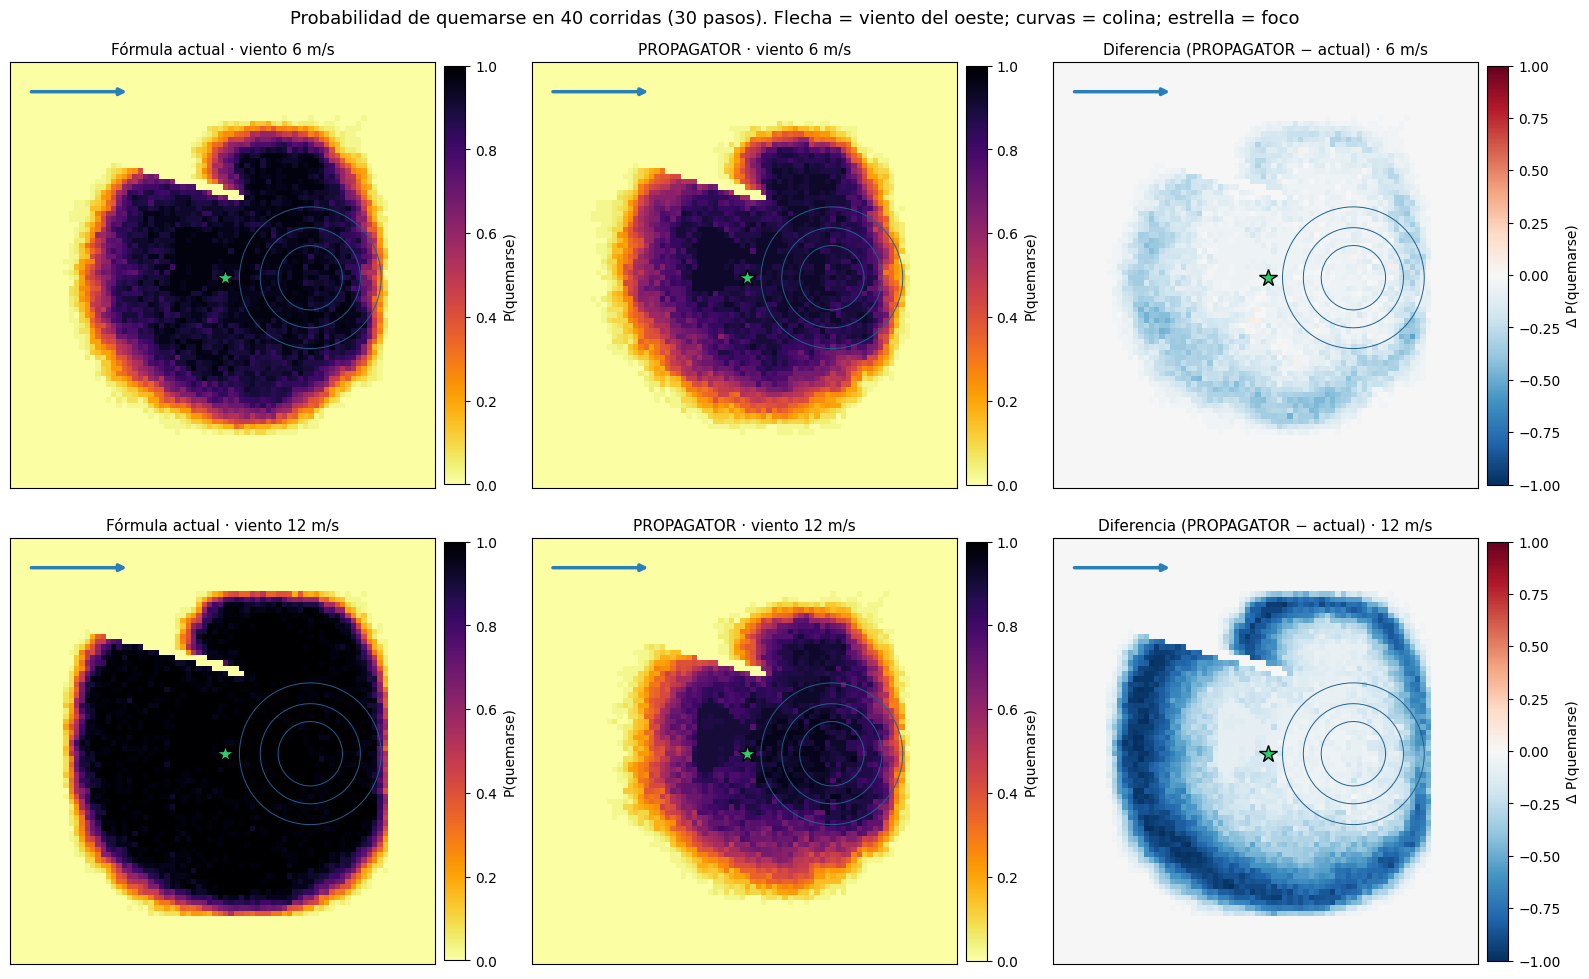

In [6]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 10))
for fila, v in enumerate(("6 m/s", "12 m/s")):
    p_actual = resultados[("Fórmula actual", v)].mean(axis=0)
    p_propagator = resultados[("PROPAGATOR", v)].mean(axis=0)
    paneles = [(p_actual, f"Fórmula actual · viento {v}", "inferno_r", 0, 1),
               (p_propagator, f"PROPAGATOR · viento {v}", "inferno_r", 0, 1),
               (p_propagator - p_actual, f"Diferencia (PROPAGATOR − actual) · {v}", "RdBu_r", -1, 1)]
    for col, (mapa, titulo, cmap, vmin, vmax) in enumerate(paneles):
        ax = ejes[fila, col]
        im = ax.imshow(mapa, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.contour(ELEVACION, levels=[200, 250, 300], colors="#1f618d", linewidths=0.7)
        ax.plot(FOCO[1], FOCO[0], "*", color="#2ecc71", ms=13, mec="k")
        ax.annotate("", xy=(22, 5), xytext=(3, 5), arrowprops=dict(arrowstyle="-|>", color="#2980b9", lw=2.5))
        ax.set_title(titulo, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="P(quemarse)" if col < 2 else "Δ P(quemarse)")
fig.suptitle(f"Probabilidad de quemarse en {N_CORRIDAS} corridas ({PASOS} pasos). "
             "Flecha = viento del oeste; curvas = colina; estrella = foco", fontsize=13)
plt.tight_layout()
plt.show()

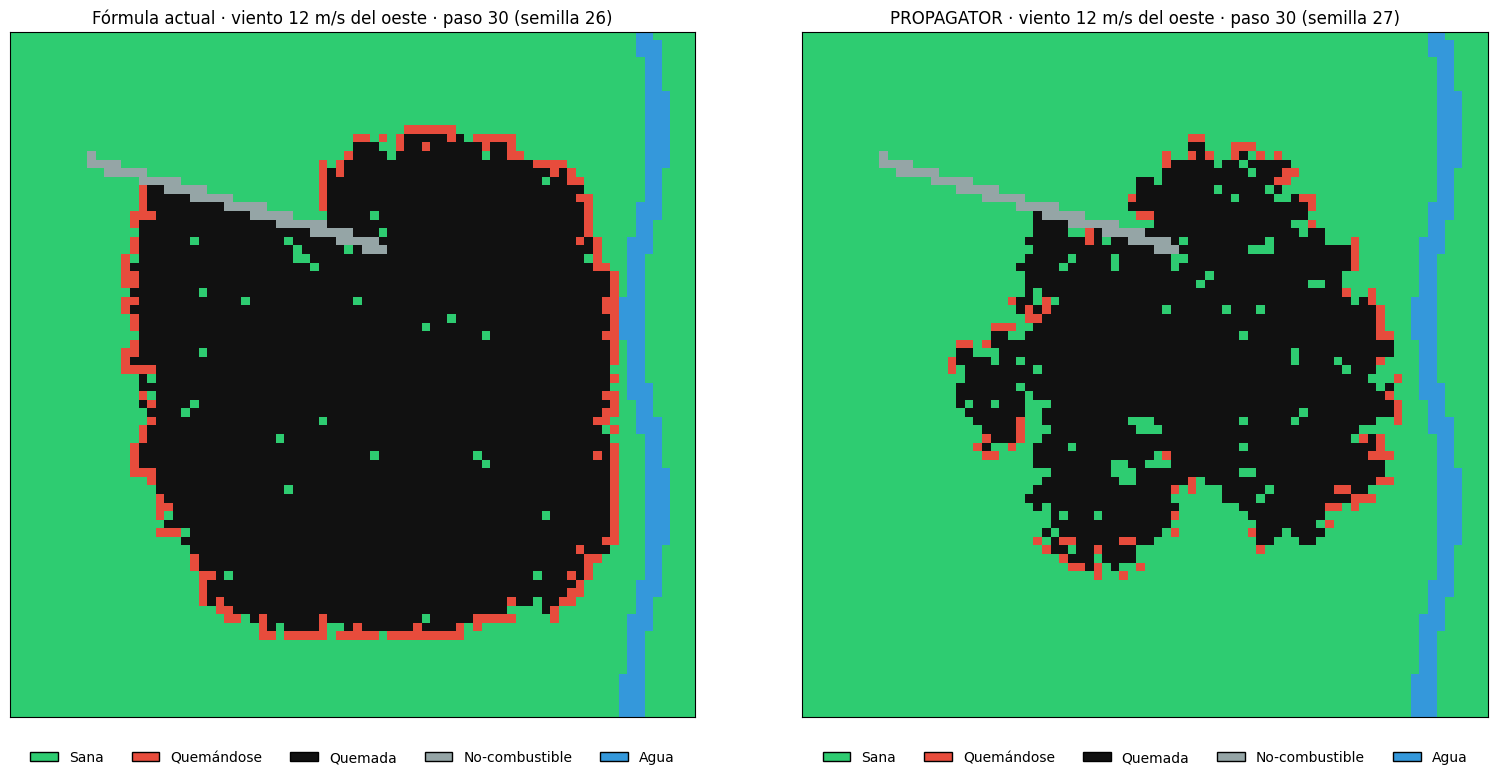

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (nombre, formulacion) in zip(ejes, (("Fórmula actual", None), ("PROPAGATOR", PROPAGATOR))):
    areas = resultados[(nombre, "12 m/s")].sum(axis=(1, 2))
    semilla = int(np.argmin(np.abs(areas - np.median(areas))))
    grid = correr(formulacion, semilla, VIENTO_FUERTE, pasos_para_quemarse=1, devolver_grid=True)
    dibujar_grid(grid, ax=ax, titulo=f"{nombre} · viento 12 m/s del oeste · paso {PASOS} (semilla {semilla})")
plt.tight_layout()
plt.show()

## Aportes por cada factor de PROPAGATOR

In [8]:
SUBIDA = (filas >= 32) & (filas <= 48) & (cols >= 46) & (cols < 56)
BAJADA = (filas >= 32) & (filas <= 48) & (cols > 56) & (cols <= 66)

sin_pendiente = FormulacionPropagator(combustible, elevacion=None, tamano_celda_m=TAMANO_CELDA)
humedad_8 = FormulacionPropagator(combustible, elevacion=ELEVACION, humedad=0.08, tamano_celda_m=TAMANO_CELDA)
variantes = {
    "PROPAGATOR completo": resultados[("PROPAGATOR", "6 m/s")],
    "PROPAGATOR sin viento": ensamble(PROPAGATOR, None, 1),
    "PROPAGATOR sin pendiente": ensamble(sin_pendiente, VIENTO_MODERADO, 1),
    "PROPAGATOR humedad 8 %": ensamble(humedad_8, VIENTO_MODERADO, 1),
    "Fórmula actual": resultados[("Fórmula actual", "6 m/s")],
    "Fórmula actual sin viento": ensamble(None, WindField(0.0, 0.0), 1),
}
imprimir_tabla([{"escenario": nombre, **resumen(m),
                 "P(quema) subida": f"{np.mean([x[SUBIDA].mean() for x in m]):.2f}",
                 "P(quema) bajada": f"{np.mean([x[BAJADA].mean() for x in m]):.2f}"}
                for nombre, m in variantes.items()])

escenario                 | área (ha) | alcance E / O (celdas) | E/O  | IoU entre corridas | P(quema) subida | P(quema) bajada
--------------------------+-----------+------------------------+------+--------------------+-----------------+----------------
PROPAGATOR completo       | 144 ± 44  | 26.2 / 22.2            | 1.18 | 0.58               | 0.90            | 0.79           
PROPAGATOR sin viento     | 93 ± 47   | 20.3 / 20.4            | 1.00 | 0.44               | 0.75            | 0.35           
PROPAGATOR sin pendiente  | 144 ± 50  | 25.8 / 22.3            | 1.16 | 0.55               | 0.86            | 0.79           
PROPAGATOR humedad 8 %    | 56 ± 31   | 20.2 / 13.2            | 1.53 | 0.35               | 0.69            | 0.30           
Fórmula actual            | 181 ± 32  | 28.2 / 25.9            | 1.09 | 0.72               | 0.95            | 0.90           
Fórmula actual sin viento | 120 ± 42  | 22.9 / 23.4            | 0.98 | 0.57               | 0.84            | 

## Análisis cuantitativo del factor de viento

In [9]:
def alexandridis_fuente(v_ms, cos_relativo, c1=DEFAULT_C1, c2=DEFAULT_C2):
    return np.exp(v_ms * (c1 + c2 * (cos_relativo - 1.0)))

P_BASE = P_NOMINAL[LATIFOLIADAS, LATIFOLIADAS]
filas_tabla = []
for v in (2.0, 6.0, 12.0):
    fila = {"viento": f"{v:.0f} m/s ({v * 3.6:.0f} km/h)"}
    versiones = {
        "actual (código)": (P_BASE * calculate_wind_factor(v, 90.0, 90.0),
                            P_BASE * calculate_wind_factor(v, 270.0, 90.0)),
        "Alexandridis (fuente)": (P_BASE * alexandridis_fuente(v, 1.0),
                                  P_BASE * alexandridis_fuente(v, -1.0)),
        "PROPAGATOR": (probabilidad_propagacion(P_BASE, factor_viento_pendiente(90.0, v * 3.6, 90.0, 0.0, TAMANO_CELDA)),
                       probabilidad_propagacion(P_BASE, factor_viento_pendiente(270.0, v * 3.6, 90.0, 0.0, TAMANO_CELDA))),
    }
    for nombre, (p_sotavento, p_barlovento) in versiones.items():
        p_sotavento, p_barlovento = min(float(p_sotavento), 1.0), min(float(p_barlovento), 1.0)
        fila[nombre + ": sotavento / barlovento"] = f"{p_sotavento:.2f} / {p_barlovento:.2f} (×{p_sotavento / p_barlovento:.1f})"
    filas_tabla.append(fila)
imprimir_tabla(filas_tabla)

viento           | actual (código): sotavento / barlovento | Alexandridis (fuente): sotavento / barlovento | PROPAGATOR: sotavento / barlovento
-----------------+-----------------------------------------+-----------------------------------------------+-----------------------------------
2 m/s (7 km/h)   | 0.33 / 0.25 (×1.3)                      | 0.33 / 0.19 (×1.7)                            | 0.32 / 0.30 (×1.1)                
6 m/s (22 km/h)  | 0.39 / 0.30 (×1.3)                      | 0.39 / 0.08 (×4.8)                            | 0.40 / 0.27 (×1.5)                
12 m/s (43 km/h) | 0.51 / 0.40 (×1.3)                      | 0.51 / 0.02 (×23.2)                           | 0.45 / 0.23 (×2.0)                
